In [2]:
import pandas as pd
from pathlib import Path
DATA_PATH = Path("/Users/vadik/brEcommerce")
tables = {
    'customers': 'olist_customers_dataset.csv', # клиенты
    'orders': 'olist_orders_dataset.csv', # заказы
    'items': 'olist_order_items_dataset.csv', # товары в заказах
    'payments': 'olist_order_payments_dataset.csv', # оплаты по заказам
    'reviews': 'olist_order_reviews_dataset.csv', # отзывы по заказам
    'products': 'olist_products_dataset.csv', # перечень товаров
    'sellers': 'olist_sellers_dataset.csv', # продавцы
    'geo': 'olist_geolocation_dataset.csv', # геолокации по зип-кодам
    'categories': 'product_category_name_translation.csv', # категории товаров
    'category_translations': 'product_category_name_translation.csv' # переводы названий категорий
}

data = {}
for name, filename in tables.items():
    filepath = DATA_PATH / filename
    if filepath.exists():
        data[name] = pd.read_csv(filepath)
        print(f"✅ {name}: {data[name].shape}")
    else:
        print(f"❌ Не найдено: {filename}")

✅ customers: (99441, 5)
✅ orders: (99441, 8)
✅ items: (112650, 7)
✅ payments: (103886, 5)
✅ reviews: (99224, 7)
✅ products: (32951, 9)
✅ sellers: (3095, 4)
✅ geo: (1000163, 5)
✅ categories: (71, 2)
✅ category_translations: (71, 2)


🚀 Задача 5: Товарная матрица (ABC-анализ)
📊 Уникальных товаров: 32,216
📦 Категорий: 74
💰 Общая выручка: £13,221,498

🎯 Принцип Парето:
   • 80% выручки дают 8,352 товаров (25.9% ассортимента)
   • 95% выручки дают 19,410 товаров (60.2% ассортимента)

📊 ABC-классификация:
           product_count  total_revenue  avg_revenue  avg_orders  avg_price  revenue_share_pct  product_share_pct
abc_class                                                                                                        
A                   8351    10577147.11      1266.57        7.50     328.15               80.0               25.9
B                  11058     1983226.62       179.35        1.96     121.88               15.0               34.3
C                  12807      661124.38        51.62        1.24      44.00                5.0               39.8

🏆 Топ-5 категорий по выручке:
 product_count  total_revenue  revenue_per_product
          2397     1233131.72           514.447943
          1300     116617

C:\Users\vadik\AppData\Local\Temp\ipykernel_6392\1027843663.py:182: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vadik\AppData\Local\Temp\ipykernel_6392\1027843663.py:183: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig('outputs/charts/abc_pareto.png', dpi=150, bbox_inches='tight')
C:\Users\vadik\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


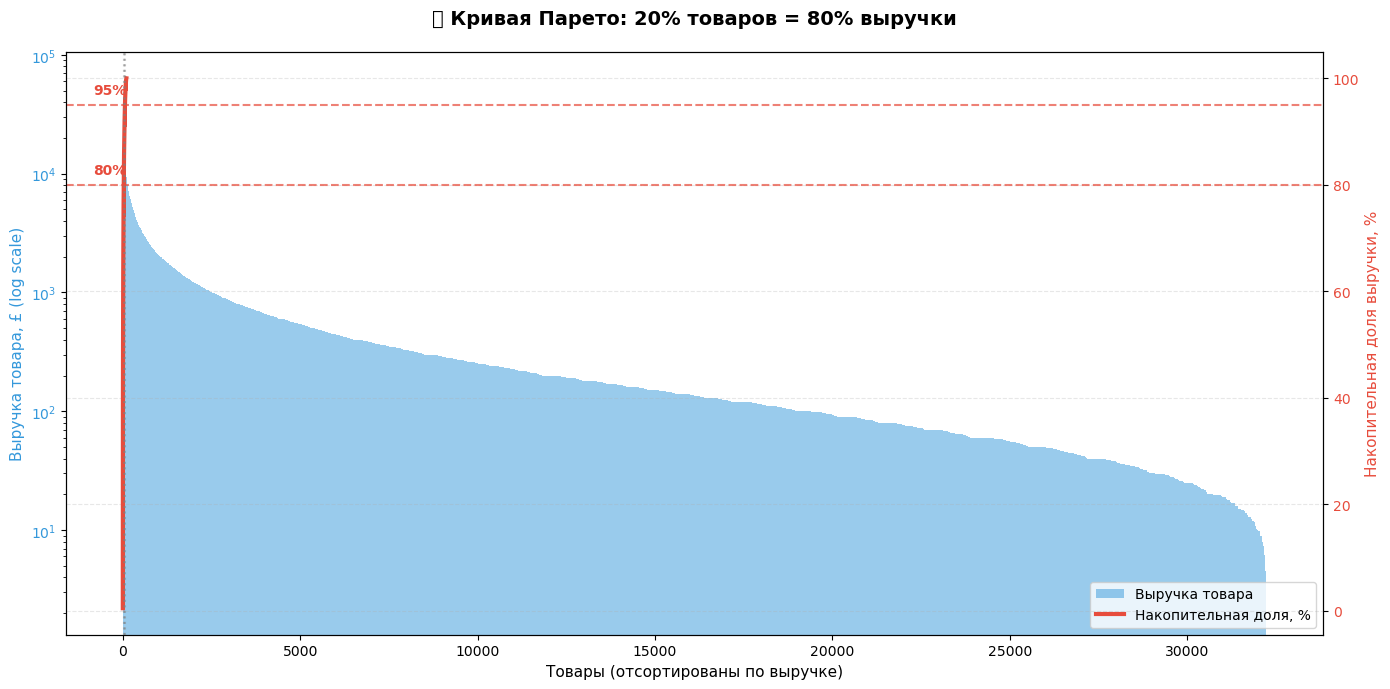

C:\Users\vadik\AppData\Local\Temp\ipykernel_6392\1027843663.py:209: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vadik\AppData\Local\Temp\ipykernel_6392\1027843663.py:210: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('outputs/charts/top_categories_revenue.png', dpi=150, bbox_inches='tight')
C:\Users\vadik\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


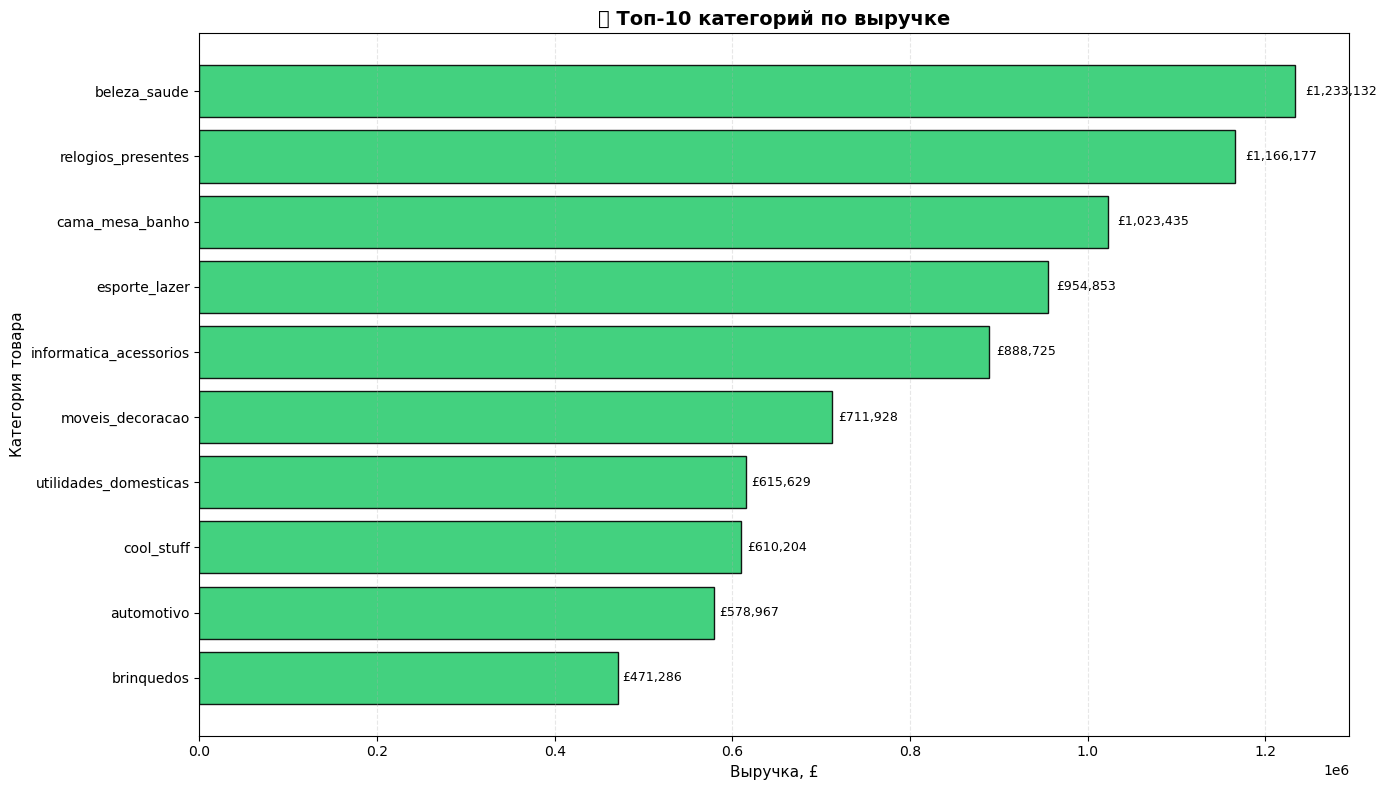

C:\Users\vadik\AppData\Local\Temp\ipykernel_6392\1027843663.py:236: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vadik\AppData\Local\Temp\ipykernel_6392\1027843663.py:237: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('outputs/charts/top_categories_efficiency.png', dpi=150, bbox_inches='tight')
C:\Users\vadik\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


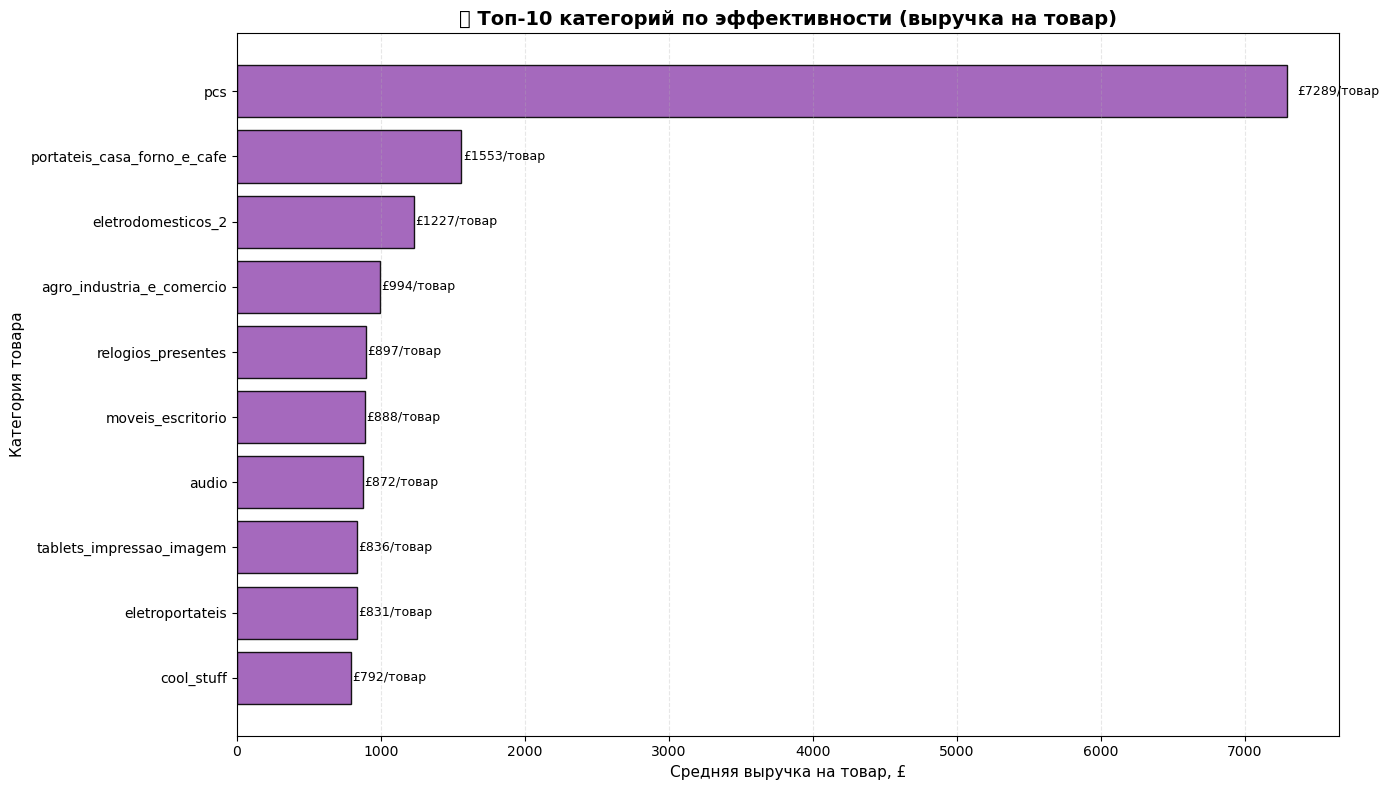


✂️ Рекомендации по оптимизации ассортимента:
   • Кандидаты на удаление: 12,730 товаров
     - Их доля в выручке: 4.95%
     - Их доля в ассортименте: 39.5%

   • Категории с высокой долей 'мусорных' товаров (>70% класса C):
     - dvds_blu_ray: 80.4% товаров — класс C
     - alimentos_bebidas: 74.7% товаров — класс C
     - artes_e_artesanato: 73.7% товаров — класс C
     - flores: 71.4% товаров — класс C
     - fashion_calcados: 71.2% товаров — класс C

✅ Артефакты сохранены:
   • outputs/charts/abc_pareto.png
   • outputs/charts/top_categories_revenue.png
   • outputs/charts/top_categories_efficiency.png
   • outputs/data/product_abc.csv
   • outputs/data/category_kpis.csv
   • docs/product_recommendations.md

🎉 Задача 5 выполнена!


In [3]:
import matplotlib.pyplot as plt

# Создаём папки для артефактов
Path('outputs/charts').mkdir(parents=True, exist_ok=True)
Path('outputs/data').mkdir(parents=True, exist_ok=True)
Path('docs').mkdir(parents=True, exist_ok=True)

print("🚀 Задача 5: Товарная матрица (ABC-анализ)")
print("=" * 70)

# =============================================================================
# 1. ПОДГОТОВКА ДАННЫХ
# =============================================================================

# Фильтруем только доставленные заказы
delivered = data['orders'][data['orders']['order_status'] == 'delivered'].copy()

# Считаем выручку по позициям (price уже является итоговой суммой за строку)
items = data['items'][['order_id', 'product_id', 'price']].copy()
items['revenue'] = items['price']

# Джойним заказы + товары + продукты
product_data = delivered.merge(items, on='order_id', how='left')
product_data = product_data.merge(
    data['products'][['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Заполняем пропущенные категории
product_data['product_category_name'] = product_data['product_category_name'].fillna('Unknown')

# Агрегируем метрики по товару
product_metrics = product_data.groupby('product_id').agg(
    category=('product_category_name', 'first'),
    revenue=('revenue', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_price=('price', 'mean')
).reset_index()

print(f"📊 Уникальных товаров: {len(product_metrics):,}")
print(f"📦 Категорий: {product_metrics['category'].nunique()}")
print(f"💰 Общая выручка: £{product_metrics['revenue'].sum():,.0f}")

# =============================================================================
# 2. КРИВАЯ ПАРЕТО (принцип 80/20)
# =============================================================================

# Сортируем по убыванию выручки
product_metrics = product_metrics.sort_values('revenue', ascending=False).reset_index(drop=True)

# Считаем накопительную выручку и долю
product_metrics['cumulative_revenue'] = product_metrics['revenue'].cumsum()
total_revenue = product_metrics['revenue'].sum()
product_metrics['revenue_share_pct'] = product_metrics['cumulative_revenue'] / total_revenue * 100

# Добавляем ранг и процент ассортимента
product_metrics['product_rank'] = range(1, len(product_metrics) + 1)
product_metrics['product_rank_pct'] = product_metrics['product_rank'] / len(product_metrics) * 100

# Находим точки 80% и 95%
pareto_80 = product_metrics[product_metrics['revenue_share_pct'] >= 80].iloc[0]
pareto_95 = product_metrics[product_metrics['revenue_share_pct'] >= 95].iloc[0]

print(f"\n🎯 Принцип Парето:")
print(f"   • 80% выручки дают {pareto_80['product_rank']:,} товаров ({pareto_80['product_rank_pct']:.1f}% ассортимента)")
print(f"   • 95% выручки дают {pareto_95['product_rank']:,} товаров ({pareto_95['product_rank_pct']:.1f}% ассортимента)")

# =============================================================================
# 3. ABC-КЛАССИФИКАЦИЯ
# =============================================================================

# Классификация по кумулятивной выручке
def classify_abc(row):
    if row['revenue_share_pct'] <= 80:
        return 'A'
    elif row['revenue_share_pct'] <= 95:
        return 'B'
    else:
        return 'C'

product_metrics['abc_class'] = product_metrics.apply(classify_abc, axis=1)

# Статистика по классам
abc_stats = product_metrics.groupby('abc_class').agg(
    product_count=('product_id', 'count'),
    total_revenue=('revenue', 'sum'),
    avg_revenue=('revenue', 'mean'),
    avg_orders=('order_count', 'mean'),
    avg_price=('avg_price', 'mean')
).round(2)

abc_stats['revenue_share_pct'] = (
    abc_stats['total_revenue'] / abc_stats['total_revenue'].sum() * 100
).round(1)
abc_stats['product_share_pct'] = (
    abc_stats['product_count'] / abc_stats['product_count'].sum() * 100
).round(1)

# Сортируем по логике классов
abc_stats = abc_stats.reindex(['A', 'B', 'C'])

print(f"\n📊 ABC-классификация:")
print(abc_stats.to_string())

# =============================================================================
# 4. АНАЛИЗ ПО КАТЕГОРИЯМ
# =============================================================================

# Агрегация по категориям
category_metrics = product_data.groupby('product_category_name').agg(
    product_count=('product_id', 'nunique'),
    total_revenue=('revenue', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_price=('price', 'mean')
).reset_index()

# Добавляем эффективность: выручка на товар
category_metrics['revenue_per_product'] = category_metrics['total_revenue'] / category_metrics['product_count']

# Топ-10 по выручке
top_categories_revenue = category_metrics.nlargest(10, 'total_revenue')

# Топ-10 по эффективности (выручка на товар)
top_categories_efficiency = category_metrics.nlargest(10, 'revenue_per_product')

print(f"\n🏆 Топ-5 категорий по выручке:")
print(top_categories_revenue[['product_count', 'total_revenue', 'revenue_per_product']].head().to_string(index=False))

# =============================================================================
# 5. ВИЗУАЛИЗАЦИЯ 1: КРИВАЯ ПАРЕТО
# =============================================================================

fig, ax1 = plt.subplots(figsize=(14, 7))

# Столбцы: выручка по товарам (логарифмическая шкала для видимости хвоста)
ax1.bar(
    product_metrics['product_rank'],
    product_metrics['revenue'],
    color='#3498db',
    alpha=0.5,
    label='Выручка товара',
    width=1
)
ax1.set_yscale('log')
ax1.set_xlabel('Товары (отсортированы по выручке)', fontsize=11)
ax1.set_ylabel('Выручка товара, £ (log scale)', fontsize=11, color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

# Линия: накопительная доля выручки
ax2 = ax1.twinx()
ax2.plot(
    product_metrics['product_rank_pct'],
    product_metrics['revenue_share_pct'],
    color='#e74c3c',
    linewidth=3,
    marker='.',
    markersize=2,
    label='Накопительная доля, %'
)
ax2.set_ylabel('Накопительная доля выручки, %', fontsize=11, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Линии-ориентиры 80% и 95%
ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axhline(y=95, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.text(98, 82, '80%', color='#e74c3c', fontsize=10, fontweight='bold', ha='right')
ax2.text(98, 97, '95%', color='#e74c3c', fontsize=10, fontweight='bold', ha='right')

# Вертикальные линии: границы классов
ax2.axvline(x=pareto_80['product_rank_pct'], color='gray', linestyle=':', alpha=0.5)
ax2.axvline(x=pareto_95['product_rank_pct'], color='gray', linestyle=':', alpha=0.5)

plt.title('📦 Кривая Парето: 20% товаров = 80% выручки', fontsize=14, fontweight='bold', pad=20)

# Легенды
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=10)

plt.grid(axis='y', alpha=0.3, linestyle='--', which='both')
plt.tight_layout()
plt.savefig('outputs/charts/abc_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 6. ВИЗУАЛИЗАЦИЯ 2: ТОП КАТЕГОРИЙ ПО ВЫРУЧКЕ
# =============================================================================

plt.figure(figsize=(14, 8))
bars = plt.barh(
    top_categories_revenue['product_category_name'],
    top_categories_revenue['total_revenue'],
    color='#2ecc71',
    edgecolor='black',
    alpha=0.9
)

# Подписи с суммами
for i, (idx, row) in enumerate(top_categories_revenue.iterrows()):
    plt.text(row['total_revenue'] + row['total_revenue']*0.01, i, 
             f"£{row['total_revenue']:,.0f}", va='center', fontsize=9)

plt.xlabel('Выручка, £', fontsize=11)
plt.ylabel('Категория товара', fontsize=11)
plt.title('🏆 Топ-10 категорий по выручке', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('outputs/charts/top_categories_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 7. ВИЗУАЛИЗАЦИЯ 3: ЭФФЕКТИВНОСТЬ КАТЕГОРИЙ (выручка на товар)
# =============================================================================

plt.figure(figsize=(14, 8))
bars = plt.barh(
    top_categories_efficiency['product_category_name'],
    top_categories_efficiency['revenue_per_product'],
    color='#9b59b6',
    edgecolor='black',
    alpha=0.9
)

# Подписи
for i, (idx, row) in enumerate(top_categories_efficiency.iterrows()):
    plt.text(row['revenue_per_product'] + row['revenue_per_product']*0.01, i, 
             f"£{row['revenue_per_product']:.0f}/товар", va='center', fontsize=9)

plt.xlabel('Средняя выручка на товар, £', fontsize=11)
plt.ylabel('Категория товара', fontsize=11)
plt.title('🎯 Топ-10 категорий по эффективности (выручка на товар)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('outputs/charts/top_categories_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 8. РЕКОМЕНДАЦИИ ПО АССОРТИМЕНТУ
# =============================================================================

# C-товары: кандидаты на удаление
c_products = product_metrics[
    (product_metrics['abc_class'] == 'C') &
    (product_metrics['order_count'] < 5) &
    (product_metrics['revenue'] < 100)
]

# Категории с высокой долей C-товаров
category_abc = product_metrics.groupby('category').agg(
    total_products=('product_id', 'count'),
    c_products=('abc_class', lambda x: (x == 'C').sum())
).reset_index()
category_abc['c_share_pct'] = category_abc['c_products'] / category_abc['total_products'] * 100
high_c_categories = category_abc[category_abc['c_share_pct'] > 70].sort_values('c_share_pct', ascending=False)

print(f"\n✂️ Рекомендации по оптимизации ассортимента:")
print(f"   • Кандидаты на удаление: {len(c_products):,} товаров")
print(f"     - Их доля в выручке: {c_products['revenue'].sum() / total_revenue * 100:.2f}%")
print(f"     - Их доля в ассортименте: {len(c_products) / len(product_metrics) * 100:.1f}%")
print(f"\n   • Категории с высокой долей 'мусорных' товаров (>70% класса C):")
for _, row in high_c_categories.head(5).iterrows():
    print(f"     - {row['category']}: {row['c_share_pct']:.1f}% товаров — класс C")

# =============================================================================
# 9. ЭКСПОРТ АРТЕФАКТОВ
# =============================================================================

# 1. ABC-классификация товаров (для загрузки в систему)
product_export = product_metrics[[
    'product_id', 'category', 'abc_class', 'revenue', 'order_count', 
    'avg_price', 'revenue_share_pct'
]].copy()
product_export.to_csv('outputs/data/product_abc.csv', index=False)

# 2. Метрики по категориям
category_export = category_metrics[[
    'product_category_name', 'product_count', 'total_revenue', 
    'order_count', 'avg_price', 'revenue_per_product'
]].copy()
category_export.to_csv('outputs/data/category_kpis.csv', index=False)

# 3. Рекомендации в Markdown
with open('docs/product_recommendations.md', 'w', encoding='utf-8') as f:
    f.write("# ✂️ Рекомендации по оптимизации ассортимента\n\n")
    f.write("## 📊 ABC-анализ: итоги\n\n")
    f.write("| Класс | Товаров | Доля в выручке | Стратегия |\n")
    f.write("|-------|---------|---------------|-----------|\n")
    for cls in ['A', 'B', 'C']:
        if cls in abc_stats.index:
            row = abc_stats.loc[cls]
            strategy = {'A': '🎯 Фокус на наличии, приоритет в закупках',
                       'B': '📊 Поддерживать, мониторить тренды',
                       'C': '✂️ Кандидаты на удаление или распродажу'}
            f.write(f"| {cls} | {int(row['product_count']):,} ({row['product_share_pct']:.1f}%) | "
                   f"£{row['total_revenue']:,.0f} ({row['revenue_share_pct']:.1f}%) | {strategy[cls]} |\n")
    
    f.write(f"\n## 🎯 Ключевые инсайты\n\n")
    f.write(f"• **{pareto_80['product_rank']:,} товаров** ({pareto_80['product_rank_pct']:.1f}% ассортимента) приносят 80% выручки.\n")
    f.write(f"• **{len(c_products):,} C-товаров** можно рассмотреть на удаление (вклад в выручку: {c_products['revenue'].sum() / total_revenue * 100:.2f}%).\n")
    f.write(f"• **Топ-3 категории по выручке**: {', '.join(top_categories_revenue['product_category_name'].head(3))}.\n")
    
    if len(high_c_categories) > 0:
        f.write(f"\n## ⚠️ Категории с высокой долей неэффективных товаров\n\n")
        f.write("| Категория | % товаров класса C | Рекомендация |\n")
        f.write("|-----------|-------------------|--------------|\n")
        for _, row in high_c_categories.head(5).iterrows():
            f.write(f"| {row['category']} | {row['c_share_pct']:.1f}% | Рассмотреть сокращение ассортимента |\n")

print(f"\n✅ Артефакты сохранены:")
print(f"   • outputs/charts/abc_pareto.png")
print(f"   • outputs/charts/top_categories_revenue.png")
print(f"   • outputs/charts/top_categories_efficiency.png")
print(f"   • outputs/data/product_abc.csv")
print(f"   • outputs/data/category_kpis.csv")
print(f"   • docs/product_recommendations.md")

print(f"\n🎉 Задача 5 выполнена!")